# MARKETING CAMPAIGN PERFORMANCE ANALYSIS

---



### UPLOADING DATASET



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv"
df = pd.read_csv(url)


### DESCRIPTIVE ANALYSIS

1. Column heads

In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


2. Number of rows and columns

In [4]:
df.shape

(22029, 16)

3. Dataset Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

4. Descriptive Statistics

In [5]:
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000
mean,11015.000000,4.757232,5522.740842,182.863648,2223.807572,50610.402787,6.582323
std,6359.368876,0.960393,2597.666260,301.619721,1394.166380,28542.979123,1.458804
min,1.000000,2.015723,1000.000000,-98.300000,30.000000,1001.000000,4.000000
25%,5508.000000,4.130705,3286.000000,-4.080000,1067.000000,25804.000000,5.000000
50%,11015.000000,4.761527,5525.000000,93.650000,2088.000000,50858.000000,7.000000
75%,16522.000000,5.429335,7766.000000,247.310000,3212.000000,75165.000000,8.000000
max,22029.000000,7.469907,9999.000000,3109.790000,6887.000000,99999.000000,9.000000


5. Unique Campaign_Id count

In [6]:
df['Campaign_ID'].nunique()

22029

6. Unique values in Location and Customer_Segment

In [ ]:
df['Location'].unique()
df['Customer_Segment'].unique()

array(['Tech Enthusiasts', 'Foodies', 'Fashionistas',
       'Outdoor Adventurers', 'Health & Wellness'], dtype=object)

7. Count occurrences of Campaign_Type

In [7]:
df['Channel_Used'].value_counts()

,count
Channel_Used,
Facebook,3742
Google Ads,3694
Website,3688
Instagram,3649
YouTube,3632
Email,3624


# EXPLORATORY DATA ANALYSIS

---



## CAMPAIGN PERFORMANCE

1. Scatter Plot : Acquisition_Cost vs ROI

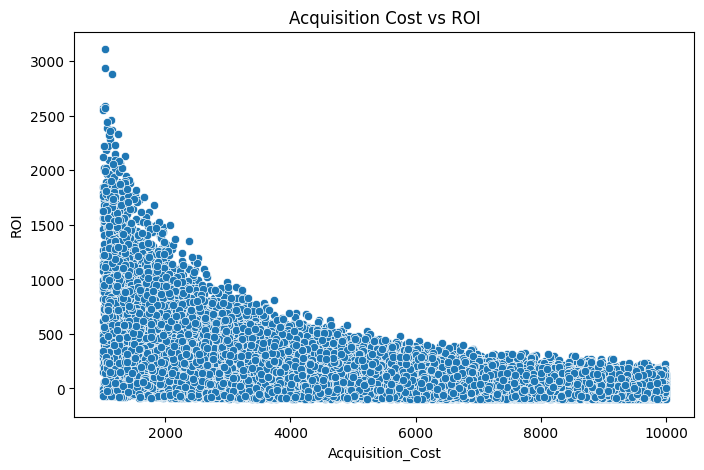

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x='Acquisition_Cost', y='ROI', data=df)
plt.title("Acquisition Cost vs ROI")
plt.show()

2. Bar Chart: Average Conversion Rate by Channel (Grouped by Campaign_Type)

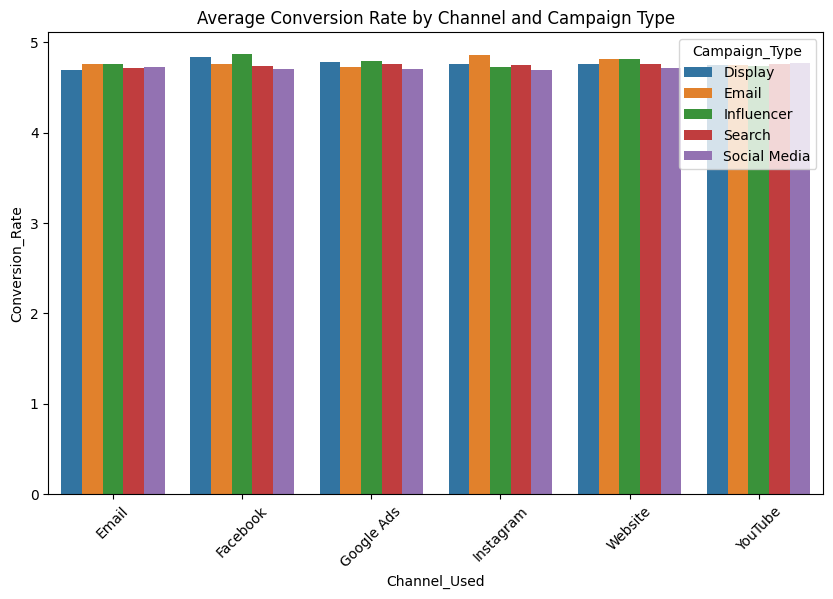

In [9]:
avg_conv = df.groupby(['Channel_Used','Campaign_Type'])['Conversion_Rate'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Channel_Used', y='Conversion_Rate', hue='Campaign_Type', data=avg_conv)
plt.xticks(rotation=45)
plt.title("Average Conversion Rate by Channel and Campaign Type")
plt.show()

3. Box Plot: Engagement Score by Campaign Type

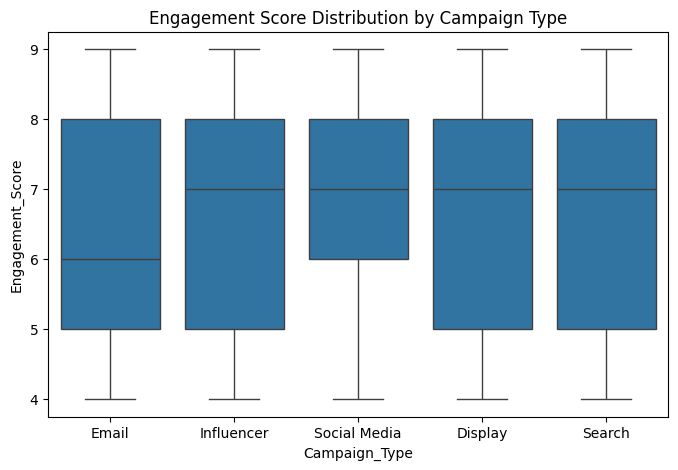

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Campaign_Type', y='Engagement_Score', data=df)
plt.title("Engagement Score Distribution by Campaign Type")
plt.show()

4. Average ROI by Company

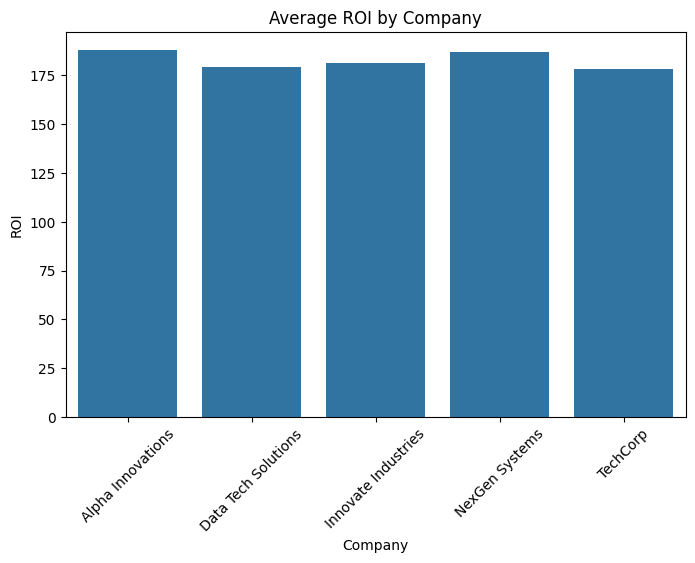

In [11]:
avg_roi = df.groupby('Company')['ROI'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Company', y='ROI', data=avg_roi)
plt.xticks(rotation=45)
plt.title("Average ROI by Company")
plt.show()

5. Heatmap: Correlation between Engagement_Score & Conversion_Rate

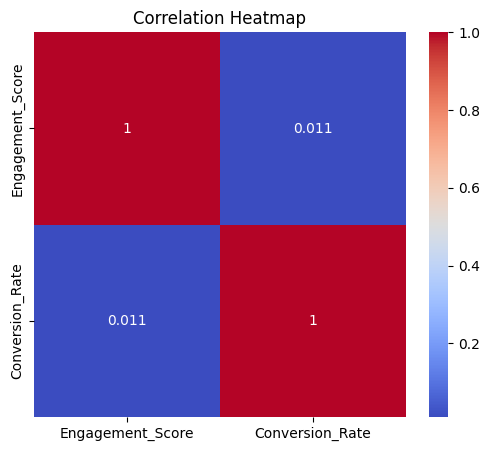

In [12]:
plt.figure(figsize=(6,5))
corr = df[['Engagement_Score','Conversion_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## CUSTOMER SEGMENTATION

1. Count Plot: Target Audience

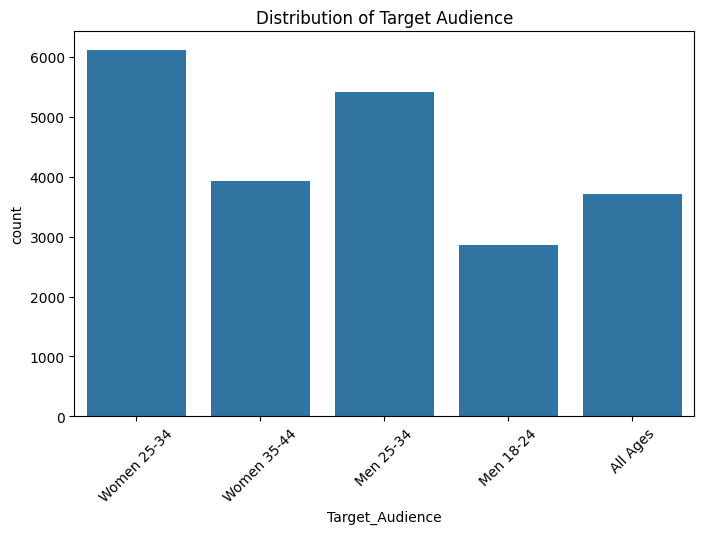

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Target_Audience', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Target Audience")
plt.show()

2. Highest Conversion Rate per Customer Segment per Language

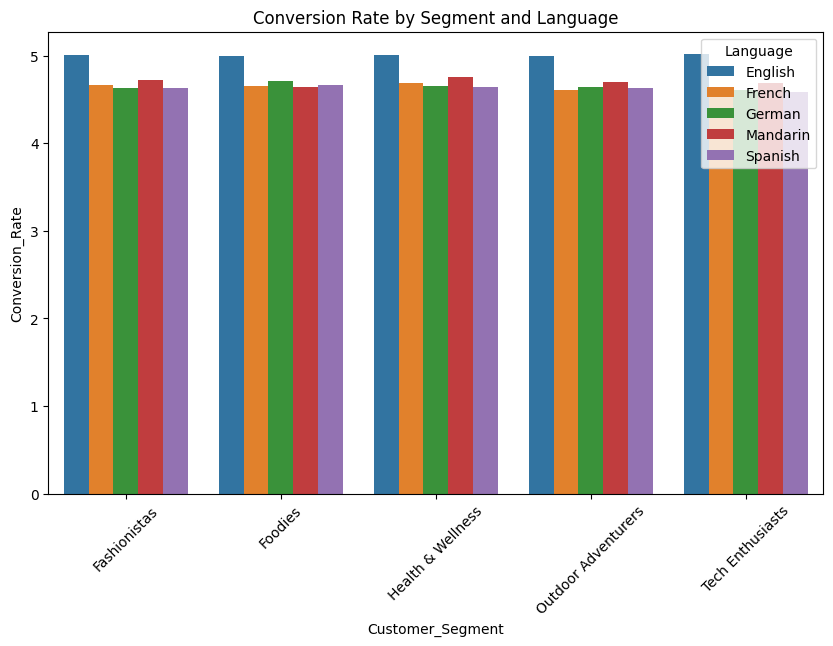

In [14]:
avg_conv_seg = df.groupby(['Customer_Segment','Language'])['Conversion_Rate'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Customer_Segment', y='Conversion_Rate', hue='Language', data=avg_conv_seg)
plt.xticks(rotation=45)
plt.title("Conversion Rate by Segment and Language")
plt.show()

3. Box Plot: Acquisition Cost across Customer Segment by Channel

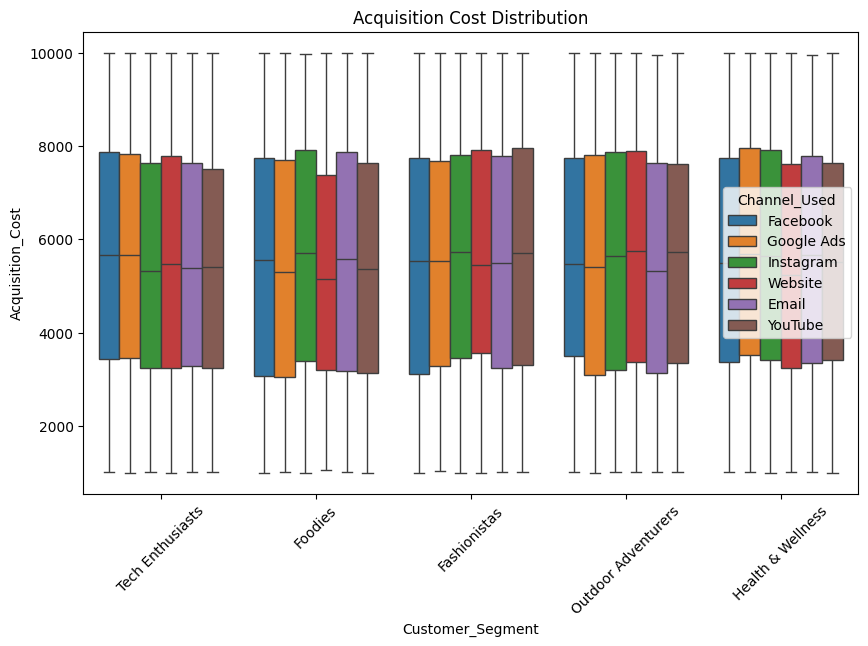

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Customer_Segment', y='Acquisition_Cost', hue='Channel_Used', data=df)
plt.xticks(rotation=45)
plt.title("Acquisition Cost Distribution")
plt.show()

4. Average Conversion Rate by Language

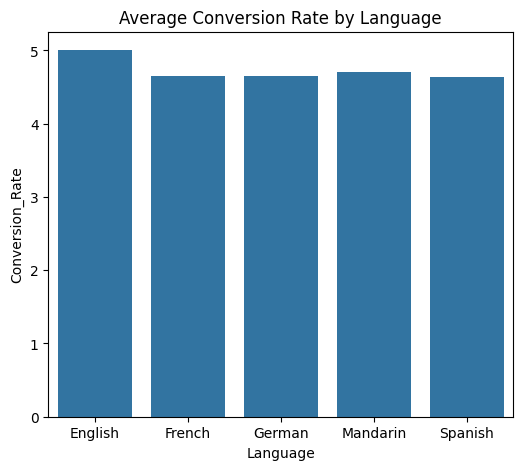

In [16]:
avg_lang = df.groupby('Language')['Conversion_Rate'].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(x='Language', y='Conversion_Rate', data=avg_lang)
plt.title("Average Conversion Rate by Language")
plt.show()

## CHANNEL EFFECTIVENESS

1. Engagement Score by Channel

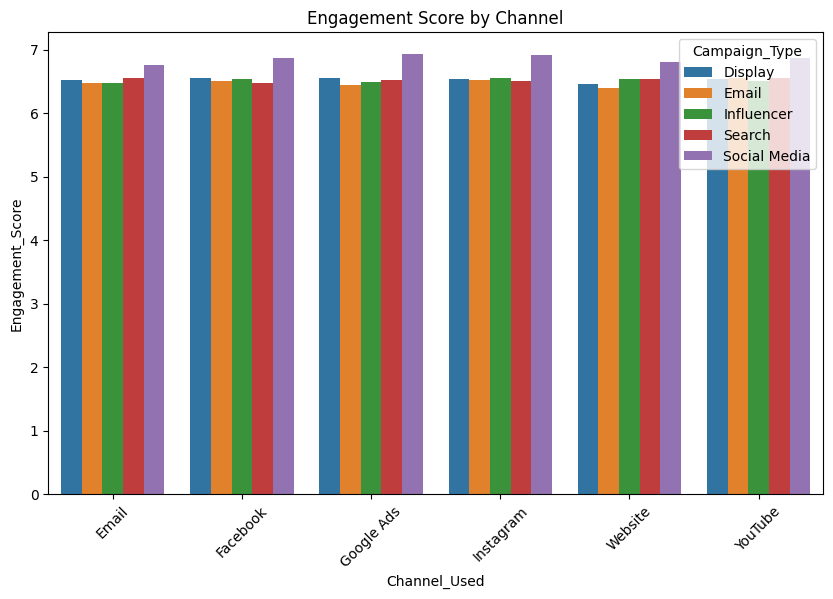

In [17]:
avg_eng = df.groupby(['Channel_Used','Campaign_Type'])['Engagement_Score'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Channel_Used', y='Engagement_Score', hue='Campaign_Type', data=avg_eng)
plt.xticks(rotation=45)
plt.title("Engagement Score by Channel")
plt.show()

2. ROI Distribution by Channel (Pie Chart)

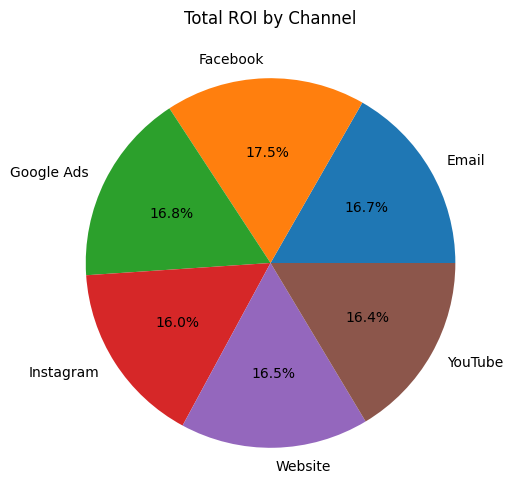

In [18]:
roi_channel = df.groupby('Channel_Used')['ROI'].sum()

plt.figure(figsize=(6,6))
plt.pie(roi_channel, labels=roi_channel.index, autopct='%1.1f%%')
plt.title("Total ROI by Channel")
plt.show()

3. Scatter Plot: Clicks vs Impressions

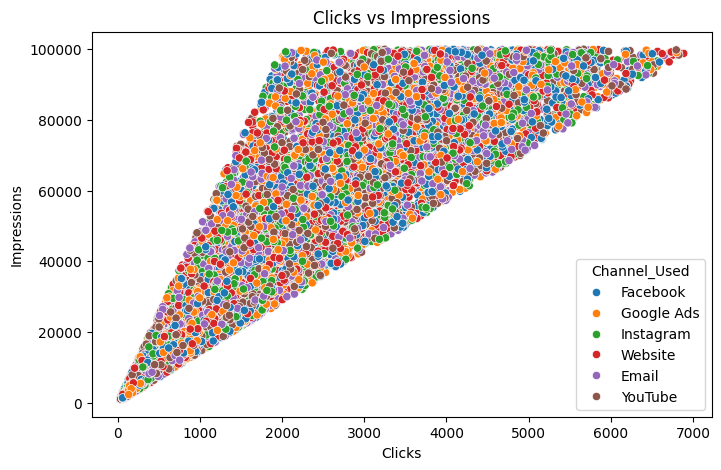

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Clicks', y='Impressions', hue='Channel_Used', data=df)
plt.title("Clicks vs Impressions")
plt.show()

## TIME-BASED ANALYSIS

Converting Date to datetime

In [21]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

1. Duration Histogram

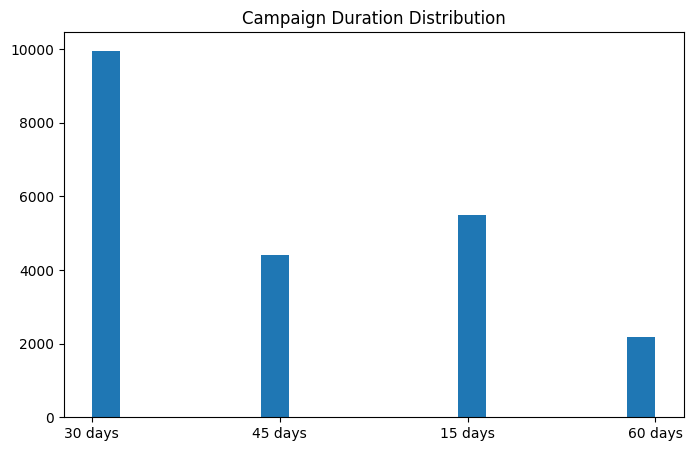

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['Duration'], bins=20)
plt.title("Campaign Duration Distribution")
plt.show()

2. Conversion Rate over Date by Company

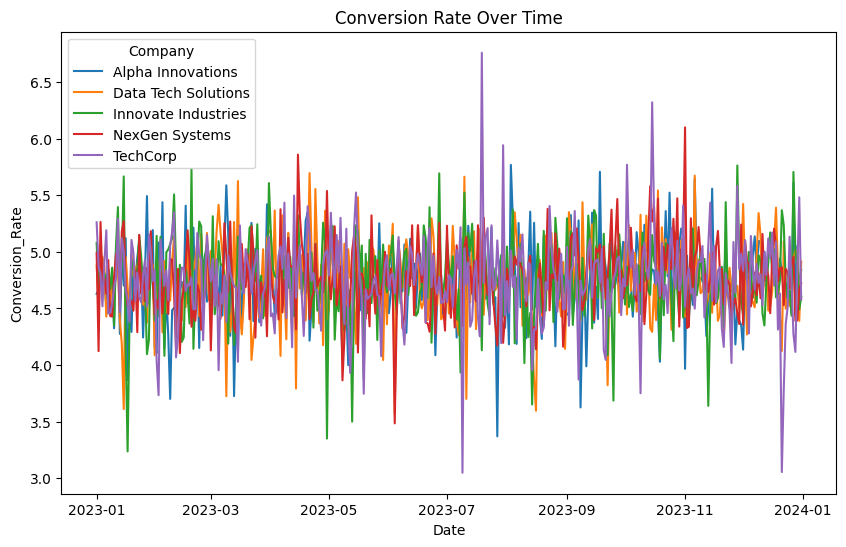

In [23]:
trend = df.groupby(['Date','Company'])['Conversion_Rate'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Conversion_Rate', hue='Company', data=trend)
plt.title("Conversion Rate Over Time")
plt.show()

3. Engagement Trend Over Time

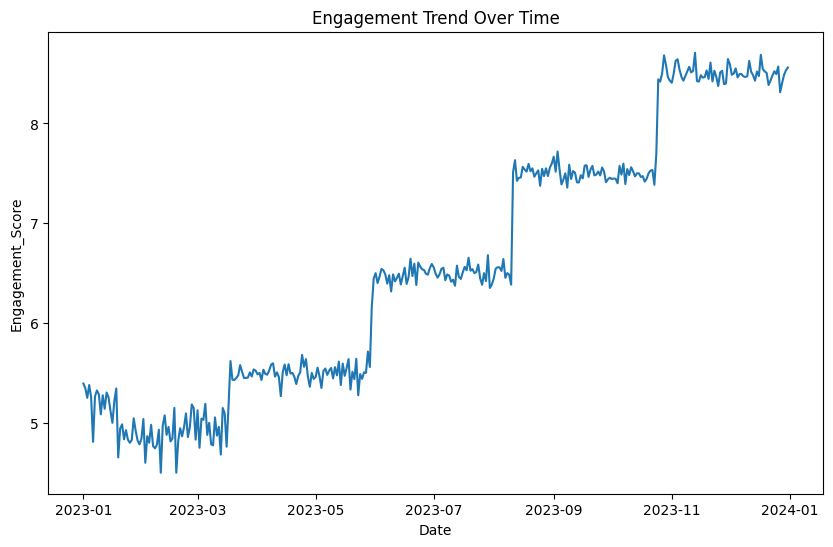

In [24]:
eng_trend = df.groupby('Date')['Engagement_Score'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Engagement_Score', data=eng_trend)
plt.title("Engagement Trend Over Time")
plt.show()

## GEOGRAPHIC ANALYSIS

1. Highest Acquisition Cost by Location

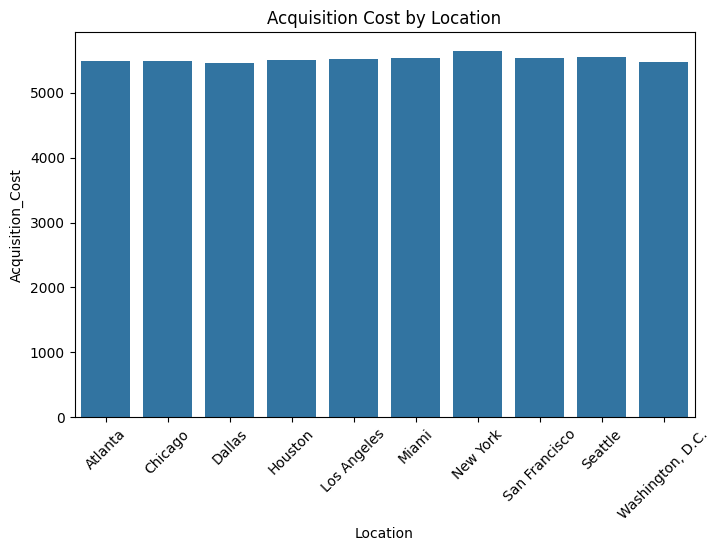

In [25]:
avg_cost = df.groupby('Location')['Acquisition_Cost'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Location', y='Acquisition_Cost', data=avg_cost)
plt.xticks(rotation=45)
plt.title("Acquisition Cost by Location")
plt.show()

2. Conversion Rate by Location and Target Audience

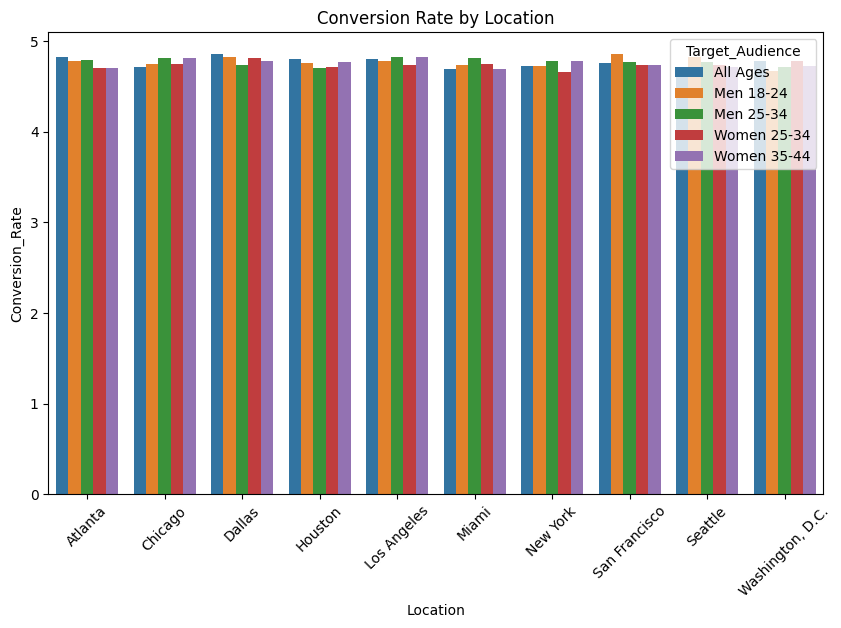

In [26]:
avg_loc = df.groupby(['Location','Target_Audience'])['Conversion_Rate'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Location', y='Conversion_Rate', hue='Target_Audience', data=avg_loc)
plt.xticks(rotation=45)
plt.title("Conversion Rate by Location")
plt.show()

3. ROI by Location (Pie Chart)

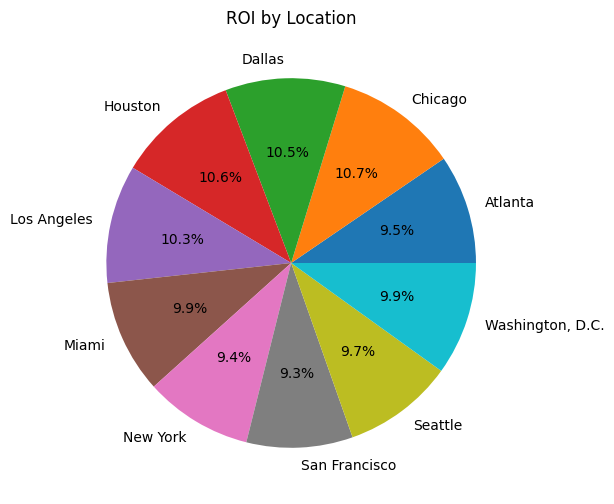

In [27]:
roi_loc = df.groupby('Location')['ROI'].sum()

plt.figure(figsize=(6,6))
plt.pie(roi_loc, labels=roi_loc.index, autopct='%1.1f%%')
plt.title("ROI by Location")
plt.show()

## KEY INSIGHTS



*   ROI decreases as Acquisition Cost increases.
*   Lower-cost campaigns tend to generate higher ROI.
*   High acquisition cost campaigns show diminishing returns.
*   Facebook shows the highest overall ROI share.
*   Engagement is relatively consistent across channels.
*   Correlation is weak between Engagement Score and Conversion Rate.
*   High engagement does not necessarily lead to higher conversions.
*   ROI performance across companies is similar, thou NexGen Systems slightly outperforms others.
*   Women and Men around the age group of 25–34 are the largest targeted segments.
*   Younger audiences show strong engagement patterns.
*   English campaigns have slightly higher average conversion rates, while other languages perform closely but marginally lower.
*   Engagement score increases steadily over time.
*   Chicago and Dallas show higher ROI contributions.
*   Acquisition cost slightly higher in New York.
*   There is strong positive relationship between clicks and impressions.
*   Higher impressions generally drive more clicks.





## RECOMMENDATIONS



*   Focus on optimizing acquisition costs rather than simply increasing spending.
*  Cost efficiency is a major driver of ROI.
*  Increase budget allocation to high-performing channels like Facebook.
*   Channel diversification is important and to be proritised to reduce dependency risk.
*   Focus should be on quality engagement rather than quantity.
*   Content strategy should be aligned.
*   Optimize landing pages to better convert engaged users.
*   Successful elements from NextGen campaigns should be replicated.
*   Standardize best-performing strategies across companies.
*   Continue prioritizing the 25–34 demographic.
*   Develop more personalized campaigns for niche segments.
*   English-language campaigns should be strongly maintained and localization strategies  should be improved for other languages.
*   Identify what changed during engagement spikes for eg.content, channel, offer.
*   High-performing time periods should be replicated.
*   Schedule campaigns strategically during high-engagement months.
*   Investment in high-performing cities like Chicago and Dallas should be increased.
*   Optimize cost structure in expensive markets like New York.
*   Customize campaigns based on regional audience behavior.
*   Geographical customization can improve RoI further.
*   CTR (Click-Through Rate) optimization strategies should be improved.
*   Refine ad creatives to convert impressions into meaningful clicks.


























## STRATEGY FOR FUTURE MARKETING


*   Prioritize cost-efficient campaigns over high-budget expansions.
*   Invest more in top-performing channels (especially Facebook).
*   Shift focus from engagement metrics to conversion-driven KPIs.
*   Strengthen localized and demographic-specific targeting.
*   Optimize campaigns in high-cost regions.
*   Implement continuous A/B testing for content and channel strategy.
*   Use data-driven budget reallocation quarterly.


